Dataset is located within shared google drive. Sign in to access.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/train'))
print(os.listdir('/content/drive/MyDrive/train'))

True
['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Using device: cuda
Total images:  7897
Classes found: ['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Class mapping: {'Glioblastoma': 0, 'Metastatic': 1, 'Schwannoma': 2, 'glioma_tumor': 3, 'meningioma_tumor': 4, 'no_tumor': 5, 'pituitary_tumor': 6}
Train samples: 6317  Val samples: 790  Test samples: 790


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Data Loaded!
Model Initialised!
Trainable parameters: 2,076 out of 11,182,179
Starting Training


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/100 | Loss: 1.1247 | Macro-F1: 0.7248
Epoch 2/100 | Loss: 0.5735 | Macro-F1: 0.8081
Epoch 3/100 | Loss: 0.5018 | Macro-F1: 0.8148
Epoch 4/100 | Loss: 0.4393 | Macro-F1: 0.8026
Epoch 5/100 | Loss: 0.4151 | Macro-F1: 0.8311
Epoch 6/100 | Loss: 0.3995 | Macro-F1: 0.7997
Epoch 7/100 | Loss: 0.3806 | Macro-F1: 0.8524
Epoch 8/100 | Loss: 0.3813 | Macro-F1: 0.8066
Epoch 9/100 | Loss: 0.3676 | Macro-F1: 0.8567
Epoch 10/100 | Loss: 0.3651 | Macro-F1: 0.8511
Epoch 11/100 | Loss: 0.3552 | Macro-F1: 0.8685
Epoch 12/100 | Loss: 0.3328 | Macro-F1: 0.8768
Epoch 13/100 | Loss: 0.3242 | Macro-F1: 0.8305
Epoch 14/100 | Loss: 0.3321 | Macro-F1: 0.8725
Epoch 15/100 | Loss: 0.3275 | Macro-F1: 0.8856
Epoch 16/100 | Loss: 0.3276 | Macro-F1: 0.8521
Epoch 17/100 | Loss: 0.3106 | Macro-F1: 0.8678
Epoch 18/100 | Loss: 0.3173 | Macro-F1: 0.8319
Epoch 19/100 | Loss: 0.3085 | Macro-F1: 0.8083
Epoch 20/100 | Loss: 0.3247 | Macro-F1: 0.8716
Epoch 21/100 | Loss: 0.3080 | Macro-F1: 0.8858
Epoch 22/100 | Loss: 0

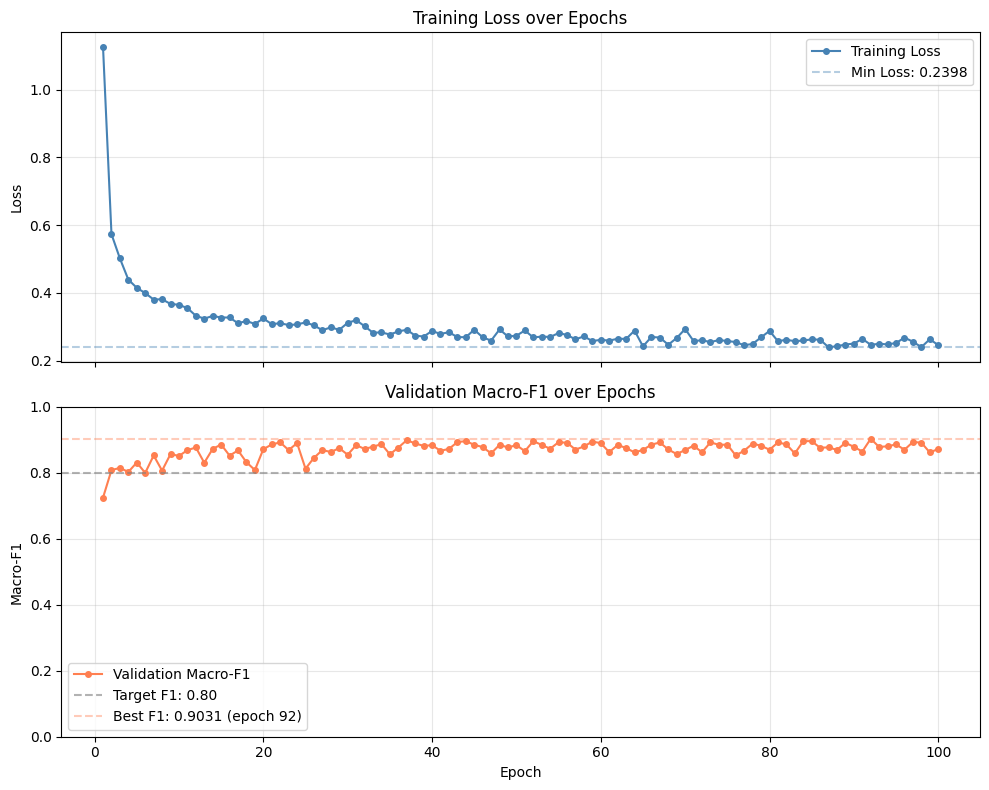

Graph saved to Google Drive
Starting Testing!
Duration of test computation:  0.6995015144348145  sec


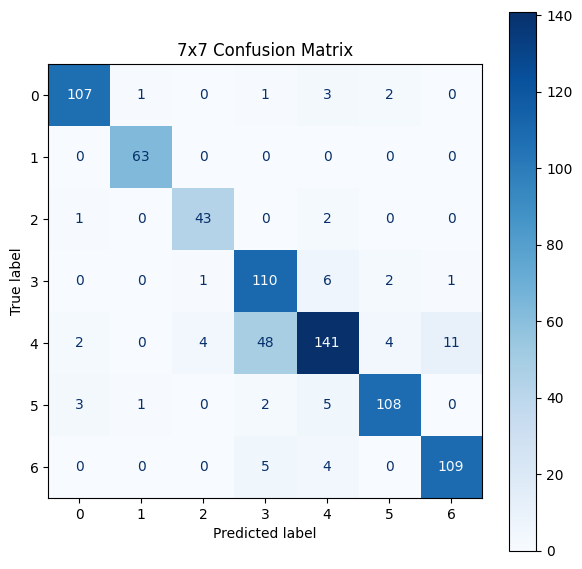

Macro F1: 0.8860887582686111
Correct indices: [137, 685, 434]
Incorrect indices: [548, 297, 361]


|| -------------------- Correctly Identified Images: -------------------- ||


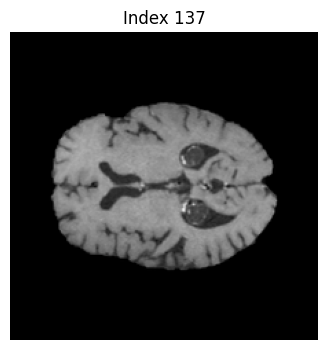

Correct class: Metastatic
Predicted class: Metastatic


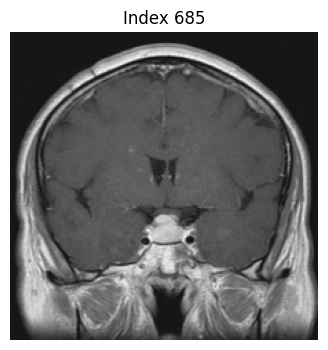

Correct class: pituitary_tumor
Predicted class: pituitary_tumor


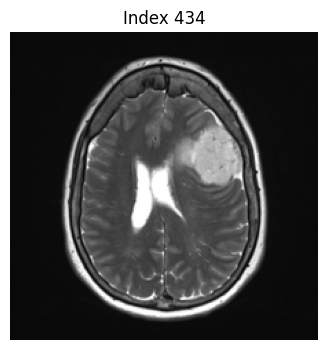

Correct class: meningioma_tumor
Predicted class: meningioma_tumor


|| -------------------- Incorrectly Identified Images: -------------------- ||


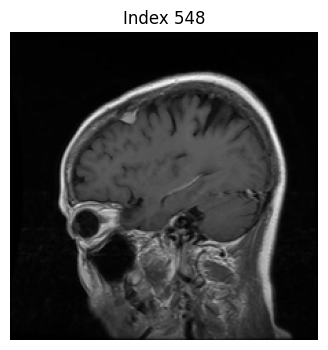

Correct class: meningioma_tumor
Predicted class: glioma_tumor


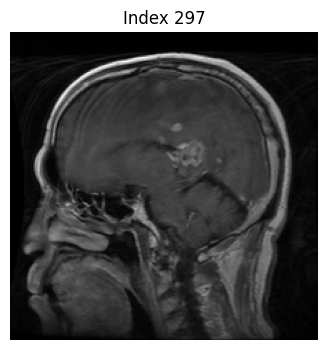

Correct class: glioma_tumor
Predicted class: pituitary_tumor


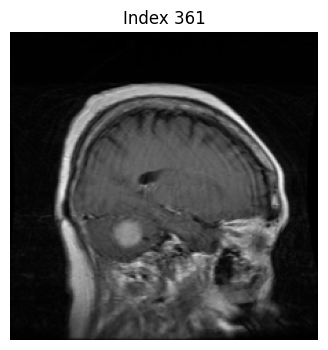

Correct class: meningioma_tumor
Predicted class: glioma_tumor


In [ ]:
import time

t0 = time.time()

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import Counter
import shutil
import os



torch.manual_seed(73)
np.random.seed(73)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# copy dataset from Google Drive to Colab local storage
print("Copying dataset to local storage...")
try:
    shutil.copytree('/content/drive/MyDrive/train', '/content/train')
except:
    print("Dataset already copied!")
print("Done!")
print(f"Files in local storage: {len(os.listdir('/content/train'))} folders")

# -------------------- load dataset -------------------- #
# location of the drive in my personal google drive -Bradly
# the way i set this up, is after Ethan shared the drive with me
# right click the folder, organize, add shortcut, then add it onto
# 'myDrive'


DATASET_PATH = '/content/train'

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)
N = len(full_dataset)

print(f"Total images:  {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")
print(f"Class mapping: {full_dataset.class_to_idx}")

train_idx = [i for i in range(N) if i % 10 not in (0, 1)]
val_idx = list(range(1, N, 10))
test_idx = list(range(0, N, 10))

train_len = len(train_idx)
val_len = len(val_idx)
test_len = len(test_idx)
print(f"Train samples: {train_len}  Val samples: {val_len}  Test samples: {test_len}")

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

batch_size = 32
num_workers = 2 # Changed from 4 to 2
train_load = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_load = DataLoader(val_ds,  batch_size=val_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)
test_load = DataLoader(test_ds,  batch_size=test_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)

print("Data Loaded!")

# -------------------- LoRA (multi-layer: layer4 + fc) -------------------- #

class LoRALinear(nn.Module):
    def __init__(self, original_layer, rank=4):
        super().__init__()
        self.original_layer = original_layer
        in_f  = original_layer.in_features
        out_f = original_layer.out_features
        for param in self.original_layer.parameters():
            param.requires_grad = False
        self.lora_A = nn.Parameter(torch.randn(in_f, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_f))
        self.rank   = rank
    def forward(self, x):
        return self.original_layer(x) + x @ self.lora_A @ self.lora_B


class LoRAConv2d(nn.Module):
    def __init__(self, original_layer: nn.Conv2d, rank: int = 4):
        super().__init__()
        self.original_layer = original_layer

        # freeze original layer parameters
        for p in self.original_layer.parameters():
            p.requires_grad = False

        # conv attributes
        self.out_ch = original_layer.out_channels
        self.in_ch = original_layer.in_channels
        ksize = original_layer.kernel_size
        if isinstance(ksize, tuple):
            self.k_h, self.k_w = ksize
        else:
            self.k_h = self.k_w = ksize
        self.groups = original_layer.groups
        self.stride = original_layer.stride
        self.padding = original_layer.padding
        self.dilation = original_layer.dilation
        self.rank = rank

        # input channels per group
        in_per_group = self.in_ch // max(1, self.groups)

        # flattened input dimension (per output row)
        in_flat = in_per_group * self.k_h * self.k_w
        out_rows = self.out_ch  # each output channel is one row

        # create LoRA parameters on same device/dtype as original weights
        w = original_layer.weight
        device, dtype = w.device, w.dtype

        # lora_A: rank x in_flat  (down projection)
        # lora_B: out_rows x rank (up projection)
        a = torch.empty((rank, in_flat), device=device, dtype=dtype)
        a.normal_(mean=0.0, std=0.01)
        b = torch.zeros((out_rows, rank), device=device, dtype=dtype)

        self.lora_A = nn.Parameter(a)
        self.lora_B = nn.Parameter(b)

        # store dims for forward
        self.in_per_group = in_per_group
        self.in_flat = in_flat
        self.out_rows = out_rows

    def forward(self, x):
        base = self.original_layer(x)

        # compute delta as (out_ch, in_flat)
        delta_flat = self.lora_B @ self.lora_A  # shape: (out_ch, in_per_group * k_h * k_w)

        # reshape to conv weight: [out_ch, in_per_group, k_h, k_w]
        delta_w = delta_flat.view(self.out_ch, self.in_per_group, self.k_h, self.k_w)

        # apply delta conv with same conv attributes (including groups)
        delta_out = F.conv2d(
            x,
            delta_w,
            bias=None,
            stride=self.stride,
            padding=self.padding,
            dilation=self.dilation,
            groups=self.groups
        )

        return base + delta_out


def apply_lora(model, rank=4):
    # freeze entire backbone
    for param in model.parameters():
        param.requires_grad = False
    # apply LoRA to layer4 conv layers
    for name, module in model.layer4.named_modules():
        if isinstance(module, nn.Conv2d):
            parts  = name.split('.')
            parent = model.layer4
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], LoRAConv2d(module, rank=rank))
            print(f"  LoRA applied to layer4.{name}")
    # apply LoRA to fc
    model.fc = LoRALinear(model.fc, rank=rank)
    print(f"  LoRA applied to fc")
    return model


def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

# -------------------- 500-epoch main model -------------------- #

def fresh_model_with_lora(rank=4):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 7)
    init.kaiming_normal_(m.fc.weight, mode='fan_in', nonlinearity='relu')
    init.zeros_(m.fc.bias)
    m = apply_lora(m, rank=rank)
    return m.to(device)


def run_training(model, num_epochs, lr, save_path):
    all_labels    = [full_dataset.samples[i][1] for i in train_idx]
    class_counts  = Counter(all_labels)
    total_samples = sum(class_counts.values())
    weights       = [total_samples / class_counts[i] for i in range(7)]
    weights       = torch.tensor(weights, dtype=torch.float).to(device)
    criterion     = nn.CrossEntropyLoss(weight=weights)
    optimizer     = optim.Adam(model.parameters(), lr=lr)
    best_f1       = 0
    losses, f1s   = [], []
    print("Starting training")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        itt_num = 0
        for images, labels in train_load:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            #print("itteration "+str(itt_num))
            #itt_num += 1

        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for images, labels in val_load:
                images = images.to(device)
                preds  = torch.argmax(model(images), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_true.extend(labels.numpy())

        macro_f1 = f1_score(all_true, all_preds, average='macro')
        avg_loss = running_loss / len(train_load)
        losses.append(avg_loss)
        f1s.append(macro_f1)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Macro-F1: {macro_f1:.4f}")

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            torch.save(model.state_dict(), save_path)
            #print(f"  New best saved! F1: {best_f1:.4f}")

    print(f"\nDone. Best Val Macro-F1: {best_f1:.4f}")
    return losses, f1s


def plot_and_save(losses, f1s, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(losses, color='steelblue')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True)
    ax2.plot(f1s, color='darkorange')
    ax2.axhline(y=0.8, color='red', linestyle='--', label='Target (0.8)')
    ax2.set_title(f'{title} — Macro-F1')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{save_name}.png', dpi=150)
    plt.show()
    print(f"Saved: {save_name}.png")


print("\n--- Running 500-epoch main model (lr=0.001, rank-4) ---")
model_main = fresh_model_with_lora(rank=4)
print("Model set up")
l_main, f_main = run_training(model_main, 500, 0.001, '/content/drive/MyDrive/main_model_best.pth')
plot_and_save(l_main, f_main, "Main Model 500ep", "main_model_curves")

model = model_main  #for test set


# -------------------- LoRA rank-16 comparison -------------------- # (uncomment this and comment the main model after main model complete)
'''
print("\n--- Running LoRA rank-16 comparison (lr=0.005, 100 epochs) ---")
model_r16    = fresh_model_with_lora(rank=16)
t16, t16c    = count_params(model_r16)
print(f"Rank-16 trainable parameters: {t16:,} out of {t16c:,}")
l_r16, f_r16 = run_training(model_r16, 100, 0.001,
                              '/content/drive/MyDrive/rank16_best.pth')
plot_and_save(l_r16, f_r16, "LoRA Rank-16 100ep", "rank16_curves")

model = model_r16 #for test set

'''

# -------------------- test with Macro-F1 value and graphs -------------------- #

model.eval() # warm up GPU if available; this code generated with prompt: "For a resnet18 model, write a short program to warm up the GPU"
with torch.no_grad():
    # warm-up iterations
    if device.type == 'cuda':
        for _ in range(3):
            _ = model(torch.randn(8, 3, 224, 224, device=device))


test_set = iter(test_load)
cur_batch, targets = next(test_set) # load the test set for testing
cur_batch = cur_batch.to(device, non_blocking=True)

t = time.time()
print("Starting Testing!")

with torch.no_grad(): # run the test batch through the model
    logits = model(cur_batch)
torch.cuda.synchronize() if device.type == 'cuda' else None

dt = time.time() - t
print("Duration of test computation: ", dt, " sec")

preds = torch.argmax(logits, dim=1) # find the index of the largest output for each image

preds_cpu = preds.cpu().numpy()
targets_cpu = targets.cpu().numpy()

labels = list(range(7))
cm = confusion_matrix(targets_cpu, preds_cpu, labels=labels) # create confusion matrix for viewing

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels) # display confusion matrix
fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("7x7 Confusion Matrix")
plt.show()

macro_f1 = f1_score(targets_cpu, preds_cpu, labels=list(range(7)), average='macro', zero_division=0) # calculate the Macro-F1 score of the test set and display it
print("Macro F1:", macro_f1)

correct_idx = [-1,-1,-1]
incorrect_idx = [-1,-1,-1]
i=0
for n in range(3):
  while correct_idx[n] == -1:
    i = (i+137)%test_len
    if preds_cpu[i] == targets_cpu[i]:
      correct_idx[n] = i
    if i==0: break
  while incorrect_idx[n] == -1:
    i = (i+137)%test_len
    if preds_cpu[i] != targets_cpu[i]:
      incorrect_idx[n] = i
    if i==0: break
print("Correct indices: "+str(correct_idx))
print("Incorrect indices: "+str(incorrect_idx))

import matplotlib.pyplot as plt # the following two functions were generated with the prompt: "How do I view the 3 correct images and 3 incorrect images with the predicted class and correct class in the following code?"
import numpy as np
import torch

def unnormalize_tensor(img_tensor, mean, std):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.numpy().transpose(1, 2, 0)
    img = np.clip(img, 0, 1)
    return img

def show_image_at_index(dataset, idx, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """
    Display the image at index idx from an ImageFolder dataset.
    - dataset: torchvision.datasets.ImageFolder
    - idx: integer index
    - mean/std: used only if the image is a normalized tensor
    """
    img, label = dataset[idx]  # dataset returns (image, label)
    class_name = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)

    # If transform returned a tensor (C,H,W)
    if isinstance(img, torch.Tensor):
        # If values are in [0,1] already and not normalized, this will still work
        try:
            img_np = unnormalize_tensor(img, mean, std)
        except Exception:
            # fallback: assume tensor already in [0,1]
            img_np = img.clone().cpu().numpy().transpose(1,2,0)
            img_np = np.clip(img_np, 0, 1)
    else:
        # PIL Image or numpy array
        try:
            img_np = np.array(img) / 255.0
        except Exception:
            raise RuntimeError("Unsupported image type: {}".format(type(img)))

    plt.figure(figsize=(4,4))
    plt.imshow(img_np)
    plt.title(f"Index {idx}")
    plt.axis('off')
    plt.show()

print("")
print("")
print("|| -------------------- Correctly Identified Images: -------------------- ||")
for n in range(3):
  show_image_at_index(test_ds, correct_idx[n])
  print("Correct class: "+str(full_dataset.classes[targets_cpu[correct_idx[n]]]))
  print("Predicted class: "+str(full_dataset.classes[preds_cpu[correct_idx[n]]]))

print("")
print("")
print("|| -------------------- Incorrectly Identified Images: -------------------- ||")
for n in range(3):
  show_image_at_index(test_ds, incorrect_idx[n])
  print("Correct class: "+str(full_dataset.classes[targets_cpu[incorrect_idx[n]]]))
  print("Predicted class: "+str(full_dataset.classes[preds_cpu[incorrect_idx[n]]]))



dt0 = time.time() - t0

print("process completed in "+str(int(dt0))+" seconds")

In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import Counter
import shutil
import os



torch.manual_seed(73)
np.random.seed(73)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# copy dataset from Google Drive to Colab local storage
print("Copying dataset to local storage...")
shutil.copytree('/content/drive/MyDrive/train', '/content/train')
print("Done!")
print(f"Files in local storage: {len(os.listdir('/content/train'))} folders")

# -------------------- load dataset -------------------- #
# location of the drive in my personal google drive -Bradly
# the way i set this up, is after Ethan shared the drive with me
# right click the folder, organize, add shortcut, then add it onto
# 'myDrive'


DATASET_PATH = '/content/train'

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)
N = len(full_dataset)

print(f"Total images:  {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")
print(f"Class mapping: {full_dataset.class_to_idx}")

train_idx = [i for i in range(N) if i % 10 not in (0, 1)]
val_idx = list(range(1, N, 10))
test_idx = list(range(0, N, 10))

train_len = len(train_idx)
val_len = len(val_idx)
test_len = len(test_idx)
print(f"Train samples: {train_len}  Val samples: {val_len}  Test samples: {test_len}")

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

batch_size = 32
num_workers = 4
train_load = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_load = DataLoader(val_ds,  batch_size=val_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)
test_load = DataLoader(test_ds,  batch_size=test_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)

print("Data Loaded!")

# -------------------- model loader -------------------- #
# Run this section independently to load a saved model and classify new images.

def build_lora_model_for_loading(rank=4):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 7)
    for param in m.parameters():
        param.requires_grad = False
    for name, module in m.layer4.named_modules():
        if isinstance(module, nn.Conv2d):
            parts  = name.split('.')
            parent = m.layer4
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], LoRAConv2d(module, rank=rank))
    m.fc = LoRALinear(m.fc, rank=rank)
    return m

MODEL_PATH  = '/content/drive/MyDrive/main_model_best.pth'
CLASS_NAMES = ['Glioblastoma', 'Metastatic', 'Schwannoma',
               'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

loaded_model = build_lora_model_for_loading(rank=4)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print(f"Model loaded from {MODEL_PATH}")

loader_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def classify_image(image_path):
    from PIL import Image
    img    = Image.open(image_path).convert('RGB')
    tensor = loader_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(loaded_model(tensor), dim=1)[0]
        pred  = torch.argmax(probs).item()
    print(f"Predicted: {CLASS_NAMES[pred]}  (confidence: {probs[pred]:.2%})")
    for name, prob in zip(CLASS_NAMES, probs):
        print(f"  {name:<20} {prob:.2%}  {'#' * int(prob * 30)}")
    return CLASS_NAMES[pred]

# To classify a new image call:
# classify_image('/content/drive/MyDrive/your_scan.jpg')
print("Loader ready!")